### Preparation

In [18]:
import os
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from torchsummary import summary
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import joblib

In [19]:
current_dir = os.getcwd()
dataset_path = os.path.join(current_dir, 'dataset')
os.makedirs(dataset_path, exist_ok=True)
os.listdir()

['4_SVM_CNN.pdf',
 'checkpoints_cnn',
 'checkpoints_cnn_100',
 'checkpoints_smo_svm',
 'dataset',
 'svm_cnn.ipynb']

In [20]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

### Create Datasets

In [ ]:
class PairedMNIST(Dataset):
    def __init__(self, root='./dataset', train=True, download=True):
        # 原始數據轉換
        transform_original = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])
        
        # 反轉數據轉換
        transform_inverted = transforms.Compose([
            transforms.ToTensor(),
            transforms.Lambda(lambda x: 1 - x),
            transforms.Normalize((0.1307,), (0.3081,))
        ])
        
        # 載入兩個數據集
        self.original_dataset = datasets.MNIST(root=root, 
                                            train=train,
                                            download=download, 
                                            transform=transform_original)
        
        self.inverted_dataset = datasets.MNIST(root=root, 
                                             train=train,
                                             download=download,
                                             transform=transform_inverted)
    
    def __len__(self):
        return len(self.original_dataset)
    
    def __getitem__(self, idx):
        orig_img, label = self.original_dataset[idx]
        inv_img, _ = self.inverted_dataset[idx]
        # 返回原始圖像、反轉圖像和標籤
        return orig_img, inv_img, label

In [22]:
BATCH_SIZE = 1024

train_dataset = PairedMNIST(train=True)
test_dataset = PairedMNIST(train=False)
    
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [23]:
def show_sample_pairs(dataset, num_samples=5):
    plt.figure(figsize=(12, 6))
    for i in range(num_samples):
        orig_img, inv_img, label = dataset[i]
        
        plt.subplot(2, num_samples, i+1)
        plt.imshow(orig_img.squeeze(), cmap='gray')
        plt.title(f'Original: {label}')
        plt.axis('off')
        
        plt.subplot(2, num_samples, i+num_samples+1)
        plt.imshow(inv_img.squeeze(), cmap='gray')
        plt.title(f'Inverted: {label}')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

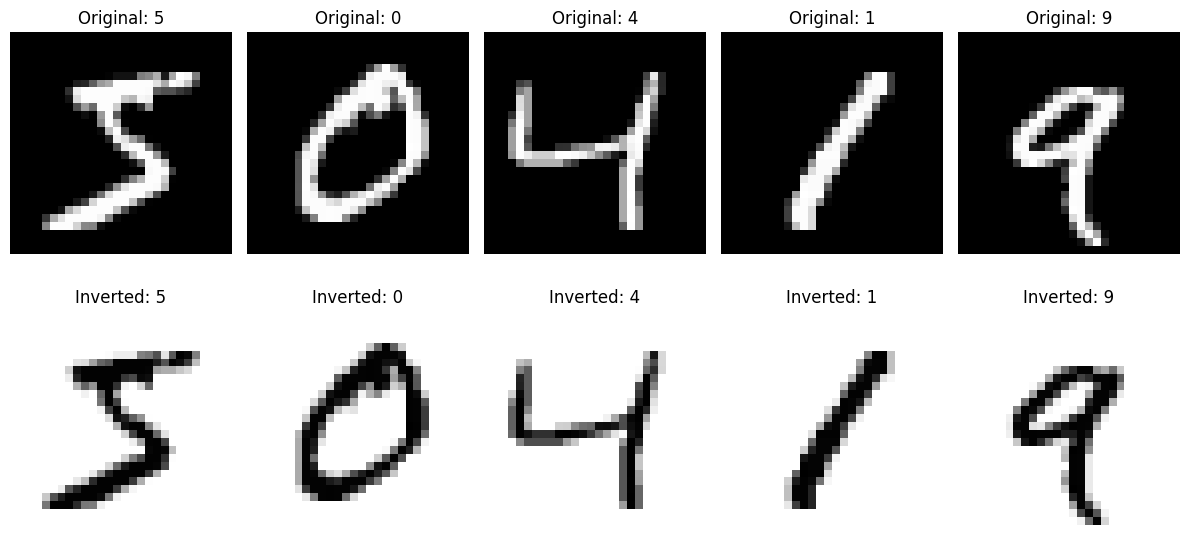

In [24]:
show_sample_pairs(PairedMNIST())

### Create CNN Module

In [25]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()
        
        # 輸入圖像大小: 28x28
        
        # C1層: 使用12個3x3卷積核生成8個特徵圖
        # 輸入: 28x28 -> 輸出: 26x26
        self.c1_left = nn.Conv2d(1, 2, kernel_size=3)  
        self.c1_right = nn.Conv2d(1, 2, kernel_size=3)  
        self.c1_both = nn.Conv2d(2, 4, kernel_size=3)   
        
        # S2層: 2x2的子採樣層
        # 輸入: 26x26 -> 輸出: 13x13
        self.s2 = nn.AvgPool2d(kernel_size=2, stride=2)
        
        # C3層: 3x3卷積核生成24個特徵圖
        # 輸入: 13x13 -> 輸出: 11x11
        self.c3 = nn.ModuleList([
            nn.Conv2d(8, 1, kernel_size=3) for _ in range(24)
        ])
        
        # S4層: 2x2的子採樣層
        # 輸入: 11x11 -> 輸出: 5x5
        self.s4 = nn.AvgPool2d(kernel_size=2, stride=2)
        
        # C5層: 3x3卷積核生成80個特徵
        # 輸入: 5x5 -> 輸出: 3x3
        self.c5 = nn.Conv2d(24, 80, kernel_size=3)
        
        # 全連接層
        self.fc = nn.Linear(80 * 3 * 3, num_classes)
        
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.uniform_(m.weight, -0.1, 0.1)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.uniform_(m.weight, -0.1, 0.1)
                nn.init.zeros_(m.bias)
    
    def forward(self, x_left, x_right):
        # 打印尺寸用於調試
        # print(f"Input size: {x_left.size()}")
        
        # C1層處理
        c1_l = torch.tanh(self.c1_left(x_left))    
        c1_r = torch.tanh(self.c1_right(x_right))  
        c1_combined = torch.cat((x_left, x_right), dim=1)
        c1_b = torch.tanh(self.c1_both(c1_combined))
        
        # 合併所有C1特徵圖
        c1 = torch.cat((c1_l, c1_r, c1_b), dim=1)  # 8個特徵圖
        # print(f"After C1: {c1.size()}")
        
        # S2層處理
        s2 = self.s2(c1)
        # print(f"After S2: {s2.size()}")
        
        # C3層處理
        c3_maps = []
        for conv in self.c3:
            c3_maps.append(torch.tanh(conv(s2)))
        c3 = torch.cat(c3_maps, dim=1)
        # print(f"After C3: {c3.size()}")
        
        # S4層處理
        s4 = self.s4(c3)
        # print(f"After S4: {s4.size()}")
        
        # C5層處理
        c5 = torch.tanh(self.c5(s4))
        # print(f"After C5: {c5.size()}")
        
        # 展平特徵
        c5_flat = c5.view(c5.size(0), -1)
        # print(f"After flatten: {c5_flat.size()}")
        
        # 輸出層
        output = self.fc(c5_flat)
        
        return output

### Check CNN Shape

In [45]:
def print_feature_maps(model, input_size=(1, 28, 28)):
    print("\n=== Feature Maps Analysis ===")
    
    # 確定模型所在的設備
    device = next(model.parameters()).device
    
    # 為左右圖像創建虛擬輸入並移至正確設備
    x_left = torch.randn(1, *input_size).to(device)
    x_right = torch.randn(1, *input_size).to(device)
    
    def get_shape_str(tensor):
        # 返回 [batch_size, channels, height, width] 格式的shape
        return f"[{tensor.shape[0]}, {tensor.shape[1]}, {tensor.shape[2]}, {tensor.shape[3]}]"
    
    print(f"\nInput images:")
    print(f"Left image shape: {get_shape_str(x_left)}")
    print(f"Right image shape: {get_shape_str(x_right)}")
    print(f"Number of input channels: 1 per image")
    
    # 追蹤每一層的feature maps
    def hook(module, input, output):
        name = module.__class__.__name__
        if isinstance(module, nn.Conv2d):
            print(f"\n{name}:")
            print(f"Output shape: {get_shape_str(output)}")
            print(f"Number of feature maps: {output.shape[1]}")
        elif isinstance(module, nn.AvgPool2d):
            print(f"\n{name}:")
            print(f"Output shape: {get_shape_str(output)}")
            print(f"Number of feature maps: {output.shape[1]} (unchanged)")
    
    # 註冊hooks
    hooks = []
    for name, layer in model.named_modules():
        if isinstance(layer, (nn.Conv2d, nn.AvgPool2d)):
            hooks.append(layer.register_forward_hook(hook))
    
    # 前向傳播
    with torch.no_grad():
        model(x_left, x_right)
    
    # 清除hooks
    for h in hooks:
        h.remove()

In [46]:
model = CNN().to(device)
print_feature_maps(model)


=== Feature Maps Analysis ===

Input images:
Left image shape: [1, 1, 28, 28]
Right image shape: [1, 1, 28, 28]
Number of input channels: 1 per image

Conv2d:
Output shape: [1, 2, 26, 26]
Number of feature maps: 2

Conv2d:
Output shape: [1, 2, 26, 26]
Number of feature maps: 2

Conv2d:
Output shape: [1, 4, 26, 26]
Number of feature maps: 4

AvgPool2d:
Output shape: [1, 8, 13, 13]
Number of feature maps: 8 (unchanged)

Conv2d:
Output shape: [1, 1, 11, 11]
Number of feature maps: 1

Conv2d:
Output shape: [1, 1, 11, 11]
Number of feature maps: 1

Conv2d:
Output shape: [1, 1, 11, 11]
Number of feature maps: 1

Conv2d:
Output shape: [1, 1, 11, 11]
Number of feature maps: 1

Conv2d:
Output shape: [1, 1, 11, 11]
Number of feature maps: 1

Conv2d:
Output shape: [1, 1, 11, 11]
Number of feature maps: 1

Conv2d:
Output shape: [1, 1, 11, 11]
Number of feature maps: 1

Conv2d:
Output shape: [1, 1, 11, 11]
Number of feature maps: 1

Conv2d:
Output shape: [1, 1, 11, 11]
Number of feature maps: 1

C

### CNN Training

In [165]:
SAVE_PATH = 'checkpoints_cnn'

def train_cnn(model, train_loader, num_epochs=20, save_path=SAVE_PATH):
    os.makedirs(save_path, exist_ok=True)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=0.001,  # 使用固定學習率
        momentum=0.9  # 保留動量項因為這對SGD很重要
    )
    
    model = model.to(device)
    
    train_losses = []
    train_accuracies = []
    best_loss = float('inf')
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for i, (left_imgs, right_imgs, labels) in enumerate(train_loader):
            left_imgs = left_imgs.to(device)
            right_imgs = right_imgs.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(left_imgs, right_imgs)
            loss = criterion(outputs, labels)
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = 100 * correct / total
        
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)
        
        print(f'Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f} Accuracy: {epoch_accuracy:.2f}%')
        
        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': best_loss,
                'accuracy': epoch_accuracy
            }, os.path.join(save_path, 'best_model.pth'))
            
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Time')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='Training Accuracy', color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Training Accuracy Over Time')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, 'training_curves.png'))
    plt.close()
    
    return train_losses, train_accuracies

### 預訓練CNN，已註解且保存權重不需再執行

In [ ]:
# model = CNN()
# losses = train_cnn(model, train_loader=train_loader)

Epoch [1/20] Loss: 2.2518 Accuracy: 22.16%
Epoch [2/20] Loss: 1.9276 Accuracy: 49.16%
Epoch [3/20] Loss: 1.3208 Accuracy: 68.81%
Epoch [4/20] Loss: 0.9010 Accuracy: 78.30%
Epoch [5/20] Loss: 0.7187 Accuracy: 81.40%
Epoch [6/20] Loss: 0.6291 Accuracy: 83.01%
Epoch [7/20] Loss: 0.5756 Accuracy: 84.08%
Epoch [8/20] Loss: 0.5392 Accuracy: 84.95%
Epoch [9/20] Loss: 0.5111 Accuracy: 85.63%
Epoch [10/20] Loss: 0.4904 Accuracy: 86.10%
Epoch [11/20] Loss: 0.4733 Accuracy: 86.61%
Epoch [12/20] Loss: 0.4583 Accuracy: 87.00%
Epoch [13/20] Loss: 0.4454 Accuracy: 87.28%
Epoch [14/20] Loss: 0.4343 Accuracy: 87.58%
Epoch [15/20] Loss: 0.4244 Accuracy: 87.84%
Epoch [16/20] Loss: 0.4158 Accuracy: 88.08%
Epoch [17/20] Loss: 0.4075 Accuracy: 88.28%
Epoch [18/20] Loss: 0.3999 Accuracy: 88.47%
Epoch [19/20] Loss: 0.3931 Accuracy: 88.64%
Epoch [20/20] Loss: 0.3865 Accuracy: 88.84%


### CNN Testing

In [171]:
def test_model(model, test_loader, device='cuda'):
    model = model.to(device)  
    model.eval()  
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():  # 不計算梯度
        for left_imgs, right_imgs, labels in test_loader:
            # 移動數據到指定設備
            left_imgs = left_imgs.to(device)
            right_imgs = right_imgs.to(device)
            labels = labels.to(device)
            
            # 前向傳播
            outputs = model(left_imgs, right_imgs)
            
            # 獲取預測結果
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # 保存預測結果和標籤用於混淆矩陣
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # 計算總體準確率
    accuracy = 100 * correct / total
    print(f'Test Accuracy: {accuracy:.2f}%')
    
    # 計算並繪製混淆矩陣
    conf_matrix = confusion_matrix(all_predictions, all_labels)
    
    return accuracy, conf_matrix

In [172]:
def confusion_matrix(predictions, labels, num_classes=10):
    """計算並繪製混淆矩陣"""
    matrix = np.zeros((num_classes, num_classes), dtype=int)
    for pred, label in zip(predictions, labels):
        matrix[label][pred] += 1
    
    # 繪製改進的混淆矩陣
    plt.figure(figsize=(12, 10))
    plt.imshow(matrix, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix', pad=20)
    plt.colorbar()
    
    # 設置刻度標籤
    class_labels = list(range(num_classes))
    plt.xticks(range(num_classes), class_labels)
    plt.yticks(range(num_classes), class_labels)
    
    # 添加數字標籤
    thresh = matrix.max() / 2.
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            plt.text(j, i, format(matrix[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if matrix[i, j] > thresh else "black")
    
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    
    # 添加每個類別的準確率統計
    print("\nPer Class Accuracy:")
    for i in range(num_classes):
        class_correct = matrix[i][i]
        class_total = matrix[i].sum()
        if class_total > 0:  # 避免除以零
            class_acc = (class_correct / class_total) * 100
            print(f"Class {i}: {class_acc:.2f}% ({class_correct}/{class_total})")
    
    plt.tight_layout()
    plt.show()

    return matrix

In [173]:
def load_best_model(model, save_path=SAVE_PATH):
    checkpoint = torch.load(os.path.join(save_path, 'best_model.pth'))
    model.load_state_dict(checkpoint['model_state_dict'])
    return model, checkpoint['epoch'], checkpoint['loss'], checkpoint['accuracy']

In [174]:
model = CNN()
model, best_epoch, best_loss, best_accuracy = load_best_model(model)
model = model.to(device)

Test Accuracy: 89.50%

Per Class Accuracy:
Class 0: 97.65% (957/980)
Class 1: 97.00% (1101/1135)
Class 2: 86.43% (892/1032)
Class 3: 88.12% (890/1010)
Class 4: 87.17% (856/982)
Class 5: 81.28% (725/892)
Class 6: 92.90% (890/958)
Class 7: 87.16% (896/1028)
Class 8: 87.47% (852/974)
Class 9: 88.31% (891/1009)


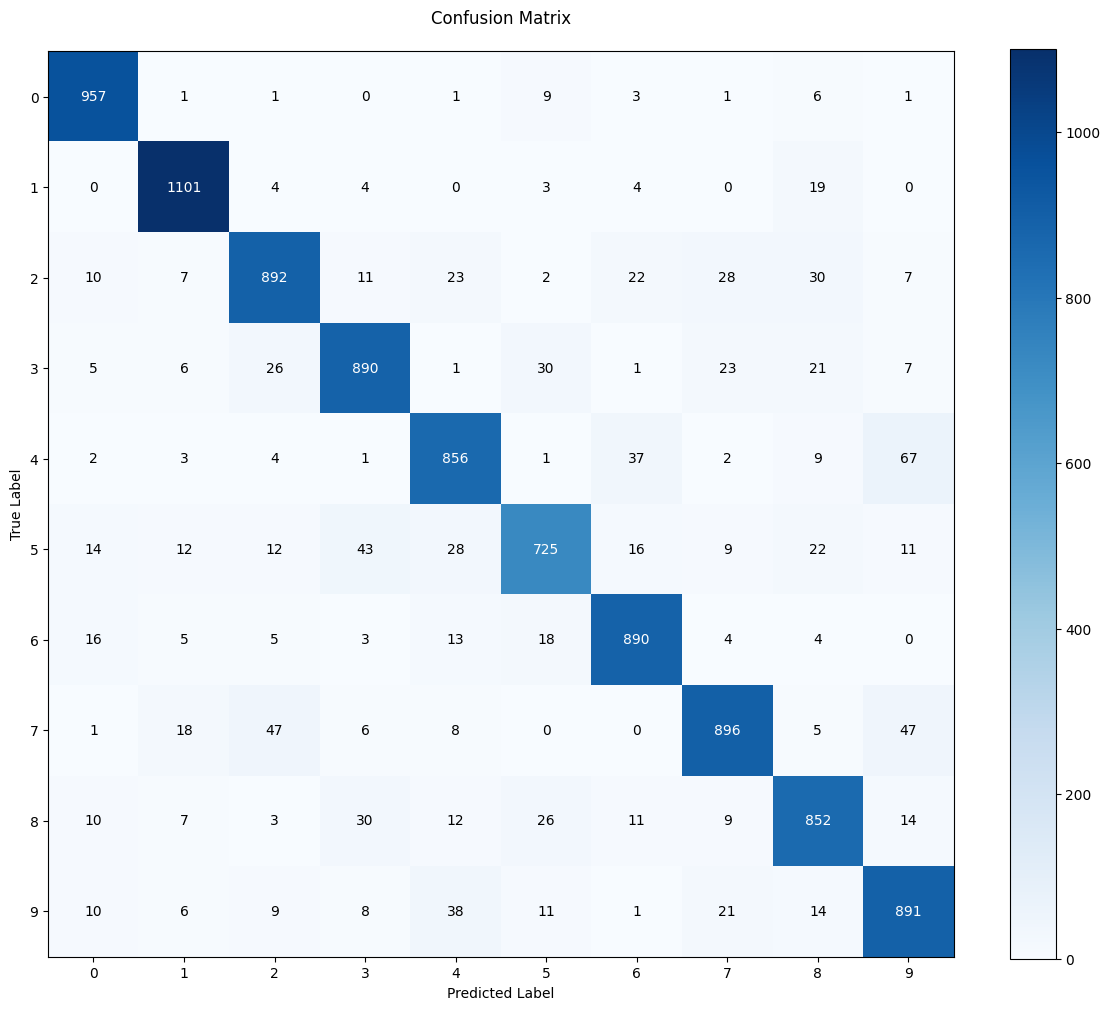

In [175]:
test_accuracy, conf_matrix = test_model(model, test_loader=test_loader)

### Create SVM Classifier

In [145]:
def prepare_data(dataloader):
    """將PyTorch的DataLoader轉換為NumPy數組"""
    X = []
    y = []
    print("Preparing Data...")
    
    for left_imgs, right_imgs, labels in dataloader:
        # 展平並連接圖像對
        batch_size = left_imgs.size(0)
        left_flat = left_imgs.view(batch_size, -1).cpu().numpy()
        right_flat = right_imgs.view(batch_size, -1).cpu().numpy()
        X_batch = np.concatenate((left_flat, right_flat), axis=1)
        X.append(X_batch)
        y.append(labels.numpy())
    
    X = np.concatenate(X, axis=0)
    y = np.concatenate(y, axis=0)
    print(f"Completed! Shape: {X.shape}")
    
    return X, y

In [146]:
class SMO_SVM:
    def __init__(self, sigma=2000, C=40):
        self.sigma = sigma
        self.C = C
        self.clf = SVC(
            kernel='rbf',
            C=self.C,
            gamma=1/(2*self.sigma**2),  # Gaussian Kernel
            cache_size=2000,
            decision_function_shape='ovr'
        )
        print(f"SVM Params Setting: sigma={self.sigma}, C={self.C}")

In [147]:
def calculate_svm_loss(model, X, y):
    """
    由於scikit-learn的SVM實現可能無法訪問內部的核矩陣，因此另外實現適用scikit-learn的損失函數
    計算SVM的損失函數值
    Loss = (1/n) * Σmax(0, 1 - y_i * f(x_i)) + (λ/2)||w||^2
    其中f(x_i)是決策函數值，y_i是標籤，w是權重向量
    """
    # 獲取決策函數值
    decision_values = model.clf.decision_function(X)
    
    # 如果是二分類問題，需要reshape決策值
    if len(decision_values.shape) == 1:
        decision_values = decision_values.reshape(-1, 1)
    
    # 計算hinge loss
    n_samples = X.shape[0]
    n_classes = decision_values.shape[1]
    
    # 創建one-hot編碼的標籤
    y_onehot = np.zeros((n_samples, n_classes))
    y_onehot[np.arange(n_samples), y] = 1
    
    # 計算margin違反
    margins = y_onehot * decision_values
    # 計算hinge loss
    losses = np.maximum(0, 1 - margins)
    
    # 計算平均損失
    avg_loss = np.mean(losses)
    
    # 獲取模型的支持向量係數作為正則化項的近似
    # 注意：這是一個近似值，因為我們無法直接訪問權重向量
    dual_coef = np.sum(model.clf.dual_coef_ ** 2)
    reg_term = 0.5 * model.C * dual_coef
    
    total_loss = avg_loss + reg_term
    
    return total_loss, avg_loss, reg_term

In [148]:
SAVE_PATH = 'checkpoints_smo_svm'

def train(model, X_train, y_train, save_path=SAVE_PATH):
    """訓練SVM模型並記錄損失"""
    os.makedirs(save_path, exist_ok=True)
    print("\nStart Training...")
    print(f"Number of Training Samples : {len(X_train)}")
    
    # 訓練模型
    model.clf.fit(X_train, y_train)
    
    # 計算訓練損失
    total_loss, hinge_loss, reg_loss = calculate_svm_loss(model, X_train, y_train)
    print(f"\nTraining Loss:")
    print(f"Total Loss: {total_loss:.4f}")
    print(f"Hinge Loss: {hinge_loss:.4f}")
    print(f"Regularization Loss: {reg_loss:.4f}")
    
    # 輸出支持向量信息
    print(f"\nNumber of Support Vectors: {model.clf.n_support_.sum()}")
    for i, n in enumerate(model.clf.n_support_):
        print(f"Number of Class {i} Support Vectors: {n} ")
    
    # 計算訓練準確率
    train_accuracy = model.clf.score(X_train, y_train) * 100
    print(f"Training Accuracy: {train_accuracy:.2f}%")
    
    # 保存模型和損失信息
    results = {
        'model': model.clf,
        'total_loss': total_loss,
        'hinge_loss': hinge_loss,
        'reg_loss': reg_loss,
        'accuracy': train_accuracy
    }
    joblib.dump(results, os.path.join(save_path, 'svm_model.joblib'))
    print(f"Model saved to: {save_path}")
    
    return train_accuracy, total_loss


In [149]:
def test(model, X_test, y_test):
    """測試SVM分類器並繪製詳細的混淆矩陣"""
    print("\nStart Testing...")
    
    # 計算測試損失
    total_loss, hinge_loss, reg_loss = calculate_svm_loss(model, X_test, y_test)
    print(f"\nTesting Loss:")
    print(f"Total Loss: {total_loss:.4f}")
    print(f"Hinge Loss: {hinge_loss:.4f}")
    print(f"Regularization Loss: {reg_loss:.4f}")
    
    # 計算測試準確率
    test_accuracy = model.clf.score(X_test, y_test) * 100
    print(f"Testing Accuracy: {test_accuracy:.2f}%")
    
    # 獲取預測結果和計算混淆矩陣
    predictions = model.clf.predict(X_test)
    conf_matrix = confusion_matrix(y_test, predictions)
    
    return test_accuracy, total_loss, conf_matrix

In [150]:
X_train, y_train = prepare_data(train_loader)
X_test, y_test = prepare_data(test_loader)

Preparing Data...
Completed! Shape: (60000, 1568)
Preparing Data...
Completed! Shape: (10000, 1568)


### 單獨 SVM Classifier 訓練時長過久

In [61]:
# svm_model = SMO_SVM(sigma=2000, C=40)
# train_accuracy, train_loss = train(svm_model, X_train, y_train)

In [62]:
# test_accuracy, test_loss = test(svm_model, X_test, y_test)

### Implement SVM_CNN

In [151]:
class Feature_Extractor(CNN):
    def __init__(self, feature_dim=80, num_classes=10):
        super(Feature_Extractor, self).__init__(num_classes)
        
        # 移除原CNN的最後一個全連接分類層
        delattr(self, 'fc')
        
        # 設置特徵維度
        self.feature_dim = feature_dim
        
    def forward(self, x_left, x_right):
        # C1層處理
        c1_l = torch.tanh(self.c1_left(x_left))    
        c1_r = torch.tanh(self.c1_right(x_right))  
        c1_combined = torch.cat((x_left, x_right), dim=1)
        c1_b = torch.tanh(self.c1_both(c1_combined))
        
        # 合併所有C1特徵圖
        c1 = torch.cat((c1_l, c1_r, c1_b), dim=1)
        
        # S2層處理
        s2 = self.s2(c1)
        
        # C3層處理
        c3_maps = []
        for conv in self.c3:
            c3_maps.append(torch.tanh(conv(s2)))
        c3 = torch.cat(c3_maps, dim=1)
        
        # S4層處理
        s4 = self.s4(c3)
        
        # C5層處理
        c5 = torch.tanh(self.c5(s4))
        
        # 展平特徵
        features = c5.view(c5.size(0), -1)
        
        return features

In [153]:
def extract_features(data_loader, model, device='cuda'):
    """從數據中提取特徵"""
    model.eval()
    features_list = []
    labels_list = []
    
    print("Extracting Features...")
    with torch.no_grad():
        for left_imgs, right_imgs, labels in data_loader:
            left_imgs = left_imgs.to(device)
            right_imgs = right_imgs.to(device)
            features = model(left_imgs, right_imgs)
            features_list.append(features.cpu().numpy())
            labels_list.append(labels.numpy())
    
    X = np.concatenate(features_list, axis=0)
    y = np.concatenate(labels_list, axis=0)
    print(f"Features Extracting Completed, Shape: {X.shape}")
    
    return X, y

In [154]:
# 創建特徵提取器和混合模型
feature_extractor = Feature_Extractor(feature_dim=80, num_classes=10).to(device)

In [155]:
# 加載預訓練的CNN權重
saved_state = torch.load('checkpoints_cnn/best_model.pth')
feature_extractor.load_state_dict(saved_state['model_state_dict'], strict=False)

_IncompatibleKeys(missing_keys=[], unexpected_keys=['fc.weight', 'fc.bias'])

In [156]:
X_train, y_train = extract_features(train_loader, feature_extractor, device)
X_test, y_test = extract_features(test_loader, feature_extractor, device)

Extracting Features...
Features Extracting Completed, Shape: (60000, 720)
Extracting Features...
Features Extracting Completed, Shape: (10000, 720)


In [157]:
model = SMO_SVM(sigma=5, C=1)

SVM Params Setting: sigma=5, C=1


### 已訓練 SVM_CNN，已註解且保存權重不需再執行

In [ ]:
# train_accuracy, train_loss = train(model, X_train, y_train)


Start Training...
Number of Training Samples : 60000

Training Loss:
Total Loss: 5761.4742
Hinge Loss: 0.9000
Regularization Loss: 5760.5742

Number of Support Vectors: 11498
Number of Class 0 Support Vectors: 753 
Number of Class 1 Support Vectors: 450 
Number of Class 2 Support Vectors: 1456 
Number of Class 3 Support Vectors: 1493 
Number of Class 4 Support Vectors: 1247 
Number of Class 5 Support Vectors: 1487 
Number of Class 6 Support Vectors: 837 
Number of Class 7 Support Vectors: 1038 
Number of Class 8 Support Vectors: 1342 
Number of Class 9 Support Vectors: 1395 
Training Accuracy: 99.29%
Model saved to: checkpoints_smo_svm


In [159]:
saved_results = joblib.load('./checkpoints_smo_svm/svm_model.joblib')
model.clf = saved_results['model']

In [160]:
print("\nLoading Trained SMO_SVM Model...")
try:
    saved_results = joblib.load(os.path.join(SAVE_PATH, 'svm_model.joblib'))
    model.clf = saved_results['model']
    print("Model Loading Successfully!")
    print(f"Training Accuracy of Loaded Model: {saved_results['accuracy']:.2f}%")
except FileNotFoundError:
    raise RuntimeError(f"Trained Model File Not Found. Make Sure To Train First\n"
                       f"Expected Path: {os.path.join(SAVE_PATH, 'svm_model.joblib')}")


Loading Trained SMO_SVM Model...
Model Loading Successfully!
Training Accuracy of Loaded Model: 99.29%



Start Testing...

Testing Loss:
Total Loss: 5761.4742
Hinge Loss: 0.9000
Regularization Loss: 5760.5742
Testing Accuracy: 97.82%

Per Class Accuracy:
Class 0: 98.98% (973/983)
Class 1: 98.69% (1128/1143)
Class 2: 97.97% (1015/1036)
Class 3: 97.34% (988/1015)
Class 4: 97.65% (954/977)
Class 5: 97.95% (861/879)
Class 6: 98.64% (944/957)
Class 7: 96.91% (1002/1034)
Class 8: 97.04% (951/980)
Class 9: 96.99% (966/996)


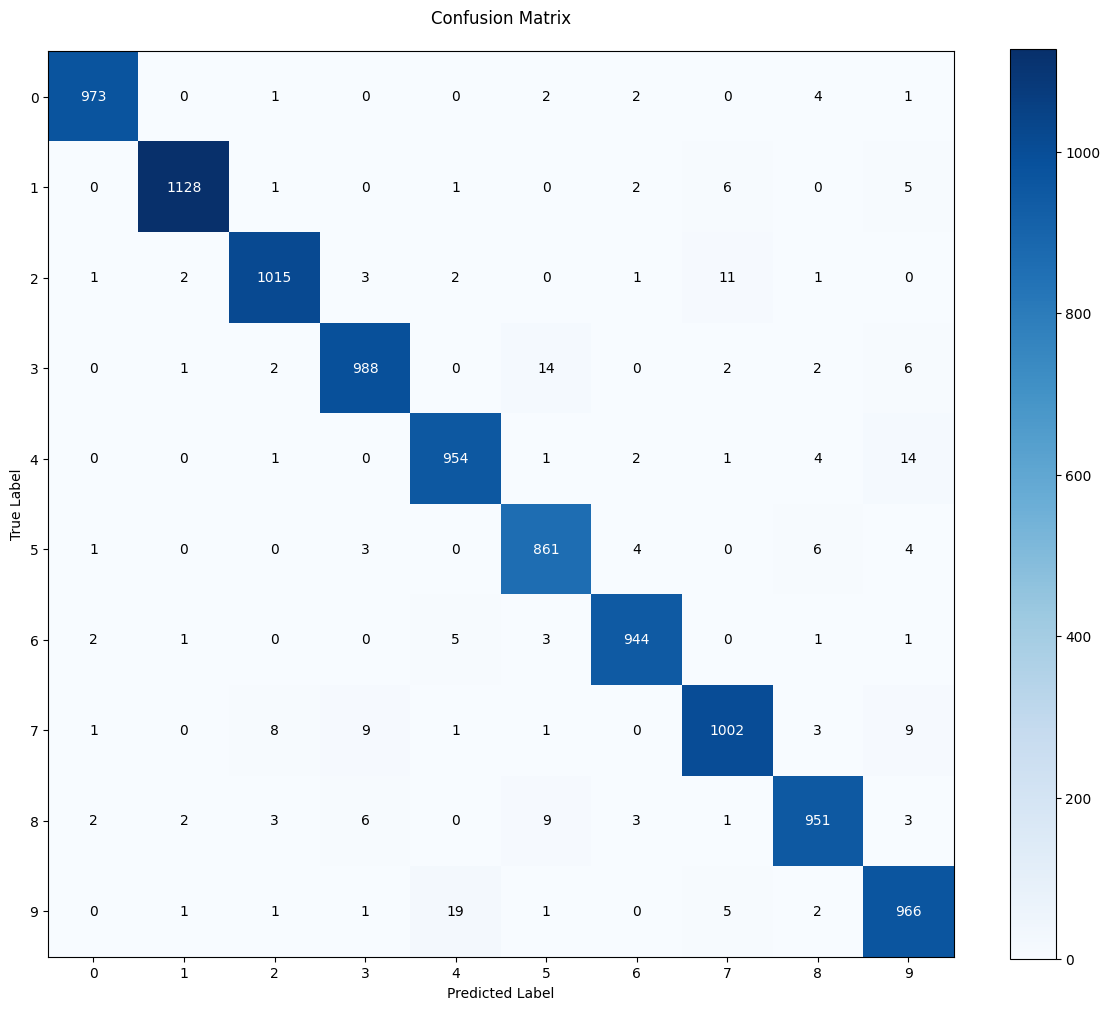

In [161]:
test_accuracy, test_loss, conf_matrix = test(model, X_test, y_test)

### CNN 100 Epochs

In [ ]:
# SAVE_PATH = 'checkpoints_cnn_100'
# model = CNN()
# losses = train_cnn(model, train_loader=train_loader, num_epochs=100, save_path=SAVE_PATH)

Epoch [1/100] Loss: 2.1944 Accuracy: 25.67%
Epoch [2/100] Loss: 1.6134 Accuracy: 61.81%
Epoch [3/100] Loss: 1.0291 Accuracy: 76.27%
Epoch [4/100] Loss: 0.7695 Accuracy: 81.02%
Epoch [5/100] Loss: 0.6543 Accuracy: 83.01%
Epoch [6/100] Loss: 0.5886 Accuracy: 84.30%
Epoch [7/100] Loss: 0.5454 Accuracy: 85.16%
Epoch [8/100] Loss: 0.5141 Accuracy: 85.88%
Epoch [9/100] Loss: 0.4893 Accuracy: 86.40%
Epoch [10/100] Loss: 0.4705 Accuracy: 86.87%
Epoch [11/100] Loss: 0.4548 Accuracy: 87.27%
Epoch [12/100] Loss: 0.4411 Accuracy: 87.63%
Epoch [13/100] Loss: 0.4290 Accuracy: 87.89%
Epoch [14/100] Loss: 0.4187 Accuracy: 88.11%
Epoch [15/100] Loss: 0.4095 Accuracy: 88.38%
Epoch [16/100] Loss: 0.4014 Accuracy: 88.60%
Epoch [17/100] Loss: 0.3936 Accuracy: 88.79%
Epoch [18/100] Loss: 0.3866 Accuracy: 88.97%
Epoch [19/100] Loss: 0.3803 Accuracy: 89.15%
Epoch [20/100] Loss: 0.3739 Accuracy: 89.28%
Epoch [21/100] Loss: 0.3688 Accuracy: 89.43%
Epoch [22/100] Loss: 0.3635 Accuracy: 89.55%
Epoch [23/100] Loss

In [184]:
SAVE_PATH = 'checkpoints_cnn_100'
model, best_epoch, best_loss, best_accuracy = load_best_model(model, save_path=SAVE_PATH)
model = model.to(device)

Test Accuracy: 94.79%

Per Class Accuracy:
Class 0: 98.57% (966/980)
Class 1: 98.59% (1119/1135)
Class 2: 93.51% (965/1032)
Class 3: 94.16% (951/1010)
Class 4: 93.79% (921/982)
Class 5: 92.26% (823/892)
Class 6: 95.93% (919/958)
Class 7: 93.39% (960/1028)
Class 8: 93.94% (915/974)
Class 9: 93.16% (940/1009)


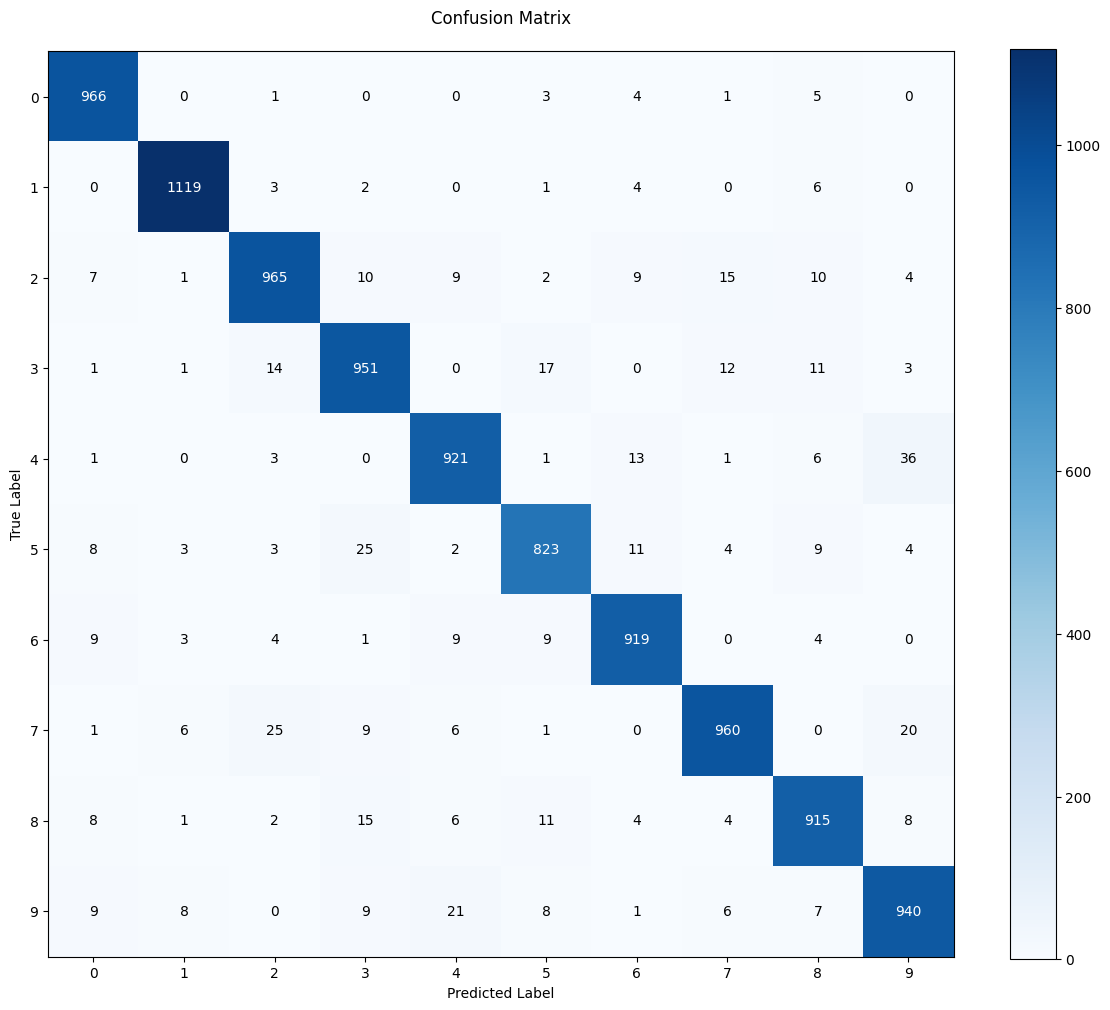

In [185]:
test_accuracy, conf_matrix = test_model(model, test_loader=test_loader)